Plotting of trajs

Current working directory: /home/nsoh/Documents/mpc_MuJoCo

Loaded file: data/2026-03-04_10-59-06_iiwa14_5/2026-03-04_10-59-06_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']

Loaded file: data/2026-03-04_11-24-12_iiwa14_200/2026-03-04_11-24-12_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']

Loaded file: data/2026-03-04_11-12-07_iiwa14_50/2026-03-04_11-12-07_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'y

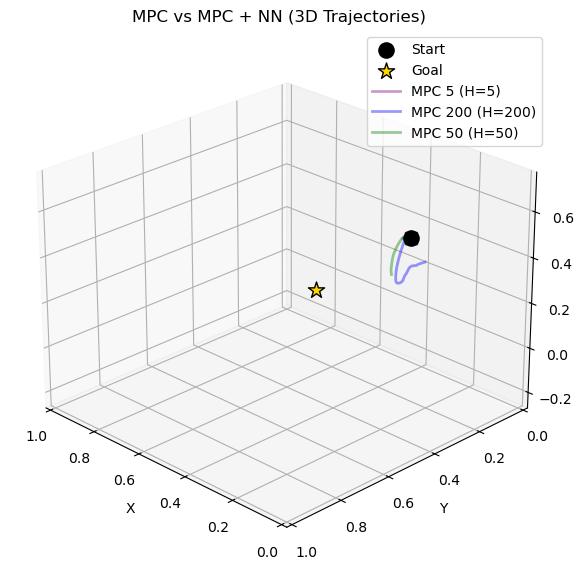

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# 1. Set project root
# --------------------------------------------------

project_root = "/home/nsoh/Documents/mpc_MuJoCo"

os.chdir(project_root)
print("Current working directory:", os.getcwd())

if project_root not in sys.path:
    sys.path.append(project_root)

from data_collection.data_utils import load_npz

# --------------------------------------------------
# 2. Load Data
# --------------------------------------------------

# nn5_data = load_npz(
#     "data/2026-02-26_12-23-53_TwoDofArm_NN_5_e38/2026-02-26_12-23-53_logs.npz"
# )

mpc_data_5 = load_npz(
    "data/2026-03-04_10-59-06_iiwa14_5/2026-03-04_10-59-06_logs.npz"
)

mpc_data_200 = load_npz(
    "data/2026-03-04_11-24-12_iiwa14_200/2026-03-04_11-24-12_logs.npz"
)

mpc_data_50 = load_npz(
    "data/2026-03-04_11-12-07_iiwa14_50/2026-03-04_11-12-07_logs.npz"
)

# --------------------------------------------------
# 3. Extract trajectories
# xyz_traj[..., 0] = x
# xyz_traj[..., 1] = y
# xyz_traj[..., 2] = z
# --------------------------------------------------

mpc_traj_5 = mpc_data_5["default"]["xyz_traj"]
mpc_traj_200 = mpc_data_200["default"]["xyz_traj"]
mpc_traj_50 = mpc_data_50["default"]["xyz_traj"]
# nn_traj_5 = nn5_data["default"]["xyz_traj"]

# Extract components
mpc_x_5 = mpc_traj_5[:, :, 0]
mpc_y_5 = mpc_traj_5[:, :, 1]
mpc_z_5 = mpc_traj_5[:, :, 2]

mpc_x_200 = mpc_traj_200[:, :, 0]
mpc_y_200 = mpc_traj_200[:, :, 1]
mpc_z_200 = mpc_traj_200[:, :, 2]

mpc_x_50 = mpc_traj_50[:, :, 0]
mpc_y_50 = mpc_traj_50[:, :, 1]
mpc_z_50 = mpc_traj_50[:, :, 2]

# nn_x_5 = nn_traj_5[:, :, 0]
# nn_y_5 = nn_traj_5[:, :, 1]
# nn_z_5 = nn_traj_5[:, :, 2]

# --------------------------------------------------
# 4. Time + horizon
# --------------------------------------------------

# T = min(
#     mpc_x_5.shape[0],
#     mpc_x_10.shape[0],
#     mpc_x_50.shape[0],
#     nn_x_5.shape[0],
# )
T = min(
    mpc_x_200.shape[0],
    mpc_x_50.shape[0],
    mpc_x_5.shape[0],
)

H_mpc_5 = mpc_x_5.shape[1] - 1
# H_mpc_10 = mpc_x_10.shape[1] - 1
H_mpc_200 = mpc_x_200.shape[1] - 1
H_mpc_50 = mpc_x_50.shape[1] - 1
# H_nn_5 = nn_x_5.shape[1] - 1

# --------------------------------------------------
# 5. Create 3D figure
# --------------------------------------------------

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("MPC vs MPC + NN (3D Trajectories)")

# ax.set_xlim(-0.8, 0.4)
# ax.set_ylim(-0.8, 0.8)
ax.set_zlim(0, 0.5)

ax.view_init(elev=25, azim=135)

# --------------------------------------------------
# Equal 3D aspect ratio
# --------------------------------------------------

def set_equal_3d(ax):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = abs(limits[:, 1] - limits[:, 0])
    centers = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

set_equal_3d(ax)

# --------------------------------------------------
# 6. Start and Goal
# --------------------------------------------------

x0 = [0.6696806406948206, -0.23525342081204376, 0.11106397173129595]
yref = [0.6045709856861988, 0.26660351212961686, 0.11348543272288131]

ax.scatter(x0[0], x0[1], x0[2],
           color="black", s=120, marker="o", label="Start")

ax.scatter(yref[0], yref[1], yref[2],
           color="gold", edgecolor="black", s=150, marker="*", label="Goal")

# --------------------------------------------------
# 7. Lines
# --------------------------------------------------

mpc_line_5, = ax.plot([], [], [], color='purple', lw=2, alpha=0.4,
                      label=f"MPC 5 (H={H_mpc_5})")

mpc_line_200, = ax.plot([], [], [], color='blue', lw=2, alpha=0.4,
                       label=f"MPC 200 (H={H_mpc_200})")

mpc_line_50, = ax.plot([], [], [], color='green', lw=2, alpha=0.4,
                       label=f"MPC 50 (H={H_mpc_50})")

# nn_line_5, = ax.plot([], [], [], color='red', lw=2, alpha=0.4,
#                      label=f"NN 5 (H={H_nn_5})")

# Current state markers
mpc_point_5, = ax.plot([], [], [], marker='s', color='purple', markersize=8)
mpc_point_200, = ax.plot([], [], [], marker='p', color='blue', markersize=8)
mpc_point_50, = ax.plot([], [], [], marker='^', color='green', markersize=8)
# nn_point_5, = ax.plot([], [], [], marker='d', color='red', markersize=8)

ax.legend()

# --------------------------------------------------
# 8. Animation update
# --------------------------------------------------

def update(t):

    # MPC 5
    mpc_line_5.set_data(mpc_x_5[t], mpc_y_5[t])
    mpc_line_5.set_3d_properties(mpc_z_5[t])
    mpc_point_5.set_data([mpc_x_5[t, 0]], [mpc_y_5[t, 0]])
    mpc_point_5.set_3d_properties([mpc_z_5[t, 0]])

    # MPC 10
    mpc_line_200.set_data(mpc_x_200[t], mpc_y_200[t])
    mpc_line_200.set_3d_properties(mpc_z_200[t])
    mpc_point_200.set_data([mpc_x_200[t, 0]], [mpc_y_200[t, 0]])
    mpc_point_200.set_3d_properties([mpc_z_200[t, 0]])

    # MPC 50
    mpc_line_50.set_data(mpc_x_50[t], mpc_y_50[t])
    mpc_line_50.set_3d_properties(mpc_z_50[t])
    mpc_point_50.set_data([mpc_x_50[t, 0]], [mpc_y_50[t, 0]])
    mpc_point_50.set_3d_properties([mpc_z_50[t, 0]])

    # # NN 5
    # nn_line_5.set_data(nn_x_5[t], nn_y_5[t])
    # nn_line_5.set_3d_properties(nn_z_5[t])
    # nn_point_5.set_data([nn_x_5[t, 0]], [nn_y_5[t, 0]])
    # nn_point_5.set_3d_properties([nn_z_5[t, 0]])

    return (
        mpc_line_5, mpc_point_5,
        mpc_line_200, mpc_point_200,
        mpc_line_50, mpc_point_50,
    )

# --------------------------------------------------
# 9. Run animation
# --------------------------------------------------

ani = FuncAnimation(fig, update, frames=T, interval=60, blit=False)
plt.show()
# ani.save("xyz_3d_animation.mp4", writer="ffmpeg", fps=30, dpi=300)

# print("Animation saved as xyz_3d_animation.mp4")

Current working directory: /home/nsoh/Documents/mpc_MuJoCo

Loaded file: data/2026-03-19_13-35-23_iiwa14/2026-03-19_13-35-23_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']

Loaded file: data/2026-03-19_13-33-57_iiwa14/2026-03-19_13-33-57_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 'yref_full', 'yref_xyz', 'u_applied', 'stage_cost', 'terminal_cost', 'total_cost', 'qpos_traj', 'qvel_traj', 'u_traj', 'sq_dist', 'GT_cost', 'GT_qpos_traj', 'GT_qvel_traj', 'xyz_traj', 'yref_q', 'xyzpos', 'GT_xyz_traj']

Loaded file: data/2026-03-04_11-12-07_iiwa14_50/2026-03-04_11-12-07_logs.npz
Total runs loaded: 1
Runs: ['default']
Variables per run: ['time', 'qpos', 'qvel', 'yref', 

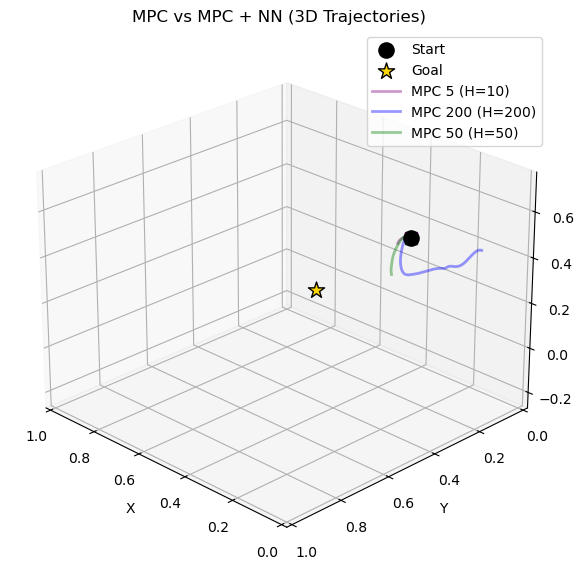

In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# 1. Set project root
# --------------------------------------------------

project_root = "/home/nsoh/Documents/mpc_MuJoCo"

os.chdir(project_root)
print("Current working directory:", os.getcwd())

if project_root not in sys.path:
    sys.path.append(project_root)

from data_collection.data_utils import load_npz

# --------------------------------------------------
# 2. Load Data
# --------------------------------------------------

# nn5_data = load_npz(
#     "data/2026-02-26_12-23-53_TwoDofArm_NN_5_e38/2026-02-26_12-23-53_logs.npz"
# )

mpc_data_5 = load_npz(
    "data/2026-03-19_13-35-23_iiwa14/2026-03-19_13-35-23_logs.npz"
)

mpc_data_200 = load_npz(
    "data/2026-03-19_13-33-57_iiwa14/2026-03-19_13-33-57_logs.npz"
)

mpc_data_50 = load_npz(
    "data/2026-03-04_11-12-07_iiwa14_50/2026-03-04_11-12-07_logs.npz"
)

# --------------------------------------------------
# 3. Extract trajectories
# xyz_traj[..., 0] = x
# xyz_traj[..., 1] = y
# xyz_traj[..., 2] = z
# --------------------------------------------------

mpc_traj_5 = mpc_data_5["default"]["xyz_traj"]
mpc_traj_200 = mpc_data_200["default"]["xyz_traj"]
mpc_traj_50 = mpc_data_50["default"]["xyz_traj"]
# nn_traj_5 = nn5_data["default"]["xyz_traj"]

# Extract components
mpc_x_5 = mpc_traj_5[:, :, 0]
mpc_y_5 = mpc_traj_5[:, :, 1]
mpc_z_5 = mpc_traj_5[:, :, 2]

mpc_x_200 = mpc_traj_200[:, :, 0]
mpc_y_200 = mpc_traj_200[:, :, 1]
mpc_z_200 = mpc_traj_200[:, :, 2]

mpc_x_50 = mpc_traj_50[:, :, 0]
mpc_y_50 = mpc_traj_50[:, :, 1]
mpc_z_50 = mpc_traj_50[:, :, 2]

# nn_x_5 = nn_traj_5[:, :, 0]
# nn_y_5 = nn_traj_5[:, :, 1]
# nn_z_5 = nn_traj_5[:, :, 2]

# --------------------------------------------------
# 4. Time + horizon
# --------------------------------------------------

# T = min(
#     mpc_x_5.shape[0],
#     mpc_x_10.shape[0],
#     mpc_x_50.shape[0],
#     nn_x_5.shape[0],
# )
T = min(
    mpc_x_200.shape[0],
    mpc_x_50.shape[0],
    mpc_x_5.shape[0],
)

H_mpc_5 = mpc_x_5.shape[1] - 1
# H_mpc_10 = mpc_x_10.shape[1] - 1
H_mpc_200 = mpc_x_200.shape[1] - 1
H_mpc_50 = mpc_x_50.shape[1] - 1
# H_nn_5 = nn_x_5.shape[1] - 1

# --------------------------------------------------
# 5. Create 3D figure
# --------------------------------------------------

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("MPC vs MPC + NN (3D Trajectories)")

# ax.set_xlim(-0.8, 0.4)
# ax.set_ylim(-0.8, 0.8)
ax.set_zlim(0, 0.5)

ax.view_init(elev=25, azim=135)

# --------------------------------------------------
# Equal 3D aspect ratio
# --------------------------------------------------

def set_equal_3d(ax):
    limits = np.array([
        ax.get_xlim3d(),
        ax.get_ylim3d(),
        ax.get_zlim3d(),
    ])
    spans = abs(limits[:, 1] - limits[:, 0])
    centers = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)

    ax.set_xlim3d([centers[0] - radius, centers[0] + radius])
    ax.set_ylim3d([centers[1] - radius, centers[1] + radius])
    ax.set_zlim3d([centers[2] - radius, centers[2] + radius])

set_equal_3d(ax)

# --------------------------------------------------
# 6. Start and Goal
# --------------------------------------------------

x0 = [0.6696806406948206, -0.23525342081204376, 0.11106397173129595]
yref = [0.6045709856861988, 0.26660351212961686, 0.11348543272288131]

ax.scatter(x0[0], x0[1], x0[2],
           color="black", s=120, marker="o", label="Start")

ax.scatter(yref[0], yref[1], yref[2],
           color="gold", edgecolor="black", s=150, marker="*", label="Goal")

# --------------------------------------------------
# 7. Lines
# --------------------------------------------------

mpc_line_5, = ax.plot([], [], [], color='purple', lw=2, alpha=0.4,
                      label=f"MPC 5 (H={H_mpc_5})")

mpc_line_200, = ax.plot([], [], [], color='blue', lw=2, alpha=0.4,
                       label=f"MPC 200 (H={H_mpc_200})")

mpc_line_50, = ax.plot([], [], [], color='green', lw=2, alpha=0.4,
                       label=f"MPC 50 (H={H_mpc_50})")

# nn_line_5, = ax.plot([], [], [], color='red', lw=2, alpha=0.4,
#                      label=f"NN 5 (H={H_nn_5})")

# Current state markers
mpc_point_5, = ax.plot([], [], [], marker='s', color='purple', markersize=8)
mpc_point_200, = ax.plot([], [], [], marker='p', color='blue', markersize=8)
mpc_point_50, = ax.plot([], [], [], marker='^', color='green', markersize=8)
# nn_point_5, = ax.plot([], [], [], marker='d', color='red', markersize=8)

ax.legend()

# --------------------------------------------------
# 8. Animation update
# --------------------------------------------------

def update(t):

    # MPC 5
    mpc_line_5.set_data(mpc_x_5[t], mpc_y_5[t])
    mpc_line_5.set_3d_properties(mpc_z_5[t])
    mpc_point_5.set_data([mpc_x_5[t, 0]], [mpc_y_5[t, 0]])
    mpc_point_5.set_3d_properties([mpc_z_5[t, 0]])

    # MPC 10
    mpc_line_200.set_data(mpc_x_200[t], mpc_y_200[t])
    mpc_line_200.set_3d_properties(mpc_z_200[t])
    mpc_point_200.set_data([mpc_x_200[t, 0]], [mpc_y_200[t, 0]])
    mpc_point_200.set_3d_properties([mpc_z_200[t, 0]])

    # MPC 50
    mpc_line_50.set_data(mpc_x_50[t], mpc_y_50[t])
    mpc_line_50.set_3d_properties(mpc_z_50[t])
    mpc_point_50.set_data([mpc_x_50[t, 0]], [mpc_y_50[t, 0]])
    mpc_point_50.set_3d_properties([mpc_z_50[t, 0]])

    # # NN 5
    # nn_line_5.set_data(nn_x_5[t], nn_y_5[t])
    # nn_line_5.set_3d_properties(nn_z_5[t])
    # nn_point_5.set_data([nn_x_5[t, 0]], [nn_y_5[t, 0]])
    # nn_point_5.set_3d_properties([nn_z_5[t, 0]])

    return (
        mpc_line_5, mpc_point_5,
        mpc_line_200, mpc_point_200,
        mpc_line_50, mpc_point_50,
    )

# --------------------------------------------------
# 9. Run animation
# --------------------------------------------------

ani = FuncAnimation(fig, update, frames=T, interval=60, blit=False)

ani.save("xyz_3d_animation.mp4", writer="ffmpeg", fps=30, dpi=300)

# print("Animation saved as xyz_3d_animation.mp4")